# 07 · Test predictions and submissions

**Goal:** the submission files for the 3,000 stage-2 test images: the 05 detectors with the 06 post-processing, then the private leaderboard scores and what they tell us. No model is trained or run here; the test boxes of every fold model (original and flipped image) and the classifier's test scores were saved by the training scripts.

**Questions**
1. How do we keep the 06 threshold valid on the test set? (section 1)
2. How to combine the 5 fold models of each detector? (section 2)
3. The 3 submission files A, B and C, and do they look right? (sections 3–4)
4. Why does the test score fall short of the consensus out-of-fold score? (sections 5–6)
5. How much do the settings gain when tuned on the leaderboard itself? (section 7)

Section 8 sums up.

Needs `patients.csv`, `test.csv`, `boxes.csv` and `npy_256/` from `scripts/prepare_data.py` and `scripts/resize_images.py`, the stage-2 test DICOMs and sample submission, the detector runs in `outputs/detection/` (validation and test boxes, original and flipped) with `ensemble_256.json` and `postprocess_256.json`, and the classifier scores in `outputs/classification/stack_384/`. The files are written to `outputs/submissions/`.

In [1]:
import json

import numpy as np
import pandas as pd
from joblib import Parallel, delayed

from rsna.boxes import nms, rank_scores, wbf
from rsna.paths import load_paths

pd.set_option("display.width", 200)
pd.set_option("display.precision", 4)

paths = load_paths()
DET = paths["outputs_dir"] / "detection"
ENSEMBLE = json.loads((DET / "ensemble_256.json").read_text())
POST = json.loads((DET / "postprocess_256.json").read_text())
classifier = pd.read_csv(paths["outputs_dir"] / "classification" / "stack_384" / "test_preds.csv").set_index("patient_id")["p_pneumonia"]
test_ids = classifier.index.to_numpy()
print(len(test_ids), "test images; box threshold", POST["box_threshold"], "classifier cut-off", POST["classifier_cutoff"])

3000 test images; box threshold 0.6 classifier cut-off 0.1


## 1. Keeping the 06 threshold valid

In 05 every box score was replaced by its rank among the out-of-fold boxes of its model and fold (0–1), and 06 chose the box threshold 0.6 on these ranks. Ranking the test boxes among themselves would change what 0.6 means: the test set has more positives, so more of its boxes are good ones. Instead each fold model's test score is placed in **the distribution of its own out-of-fold scores**: a test box gets the percentile rank its score would have among that fold model's validation boxes. 0.6 then means the same as in 06.

Per fold model, as in 05: NMS on the original and the flipped boxes, WBF of the two. Check: the mapping applied to the validation boxes themselves gives back the ranks of 05:

In [2]:
def nms_at(pred, iou):
    return pred if iou == "own" else nms(pred, iou)


def tta_boxes(run, cfg, split):
    """One fold model's boxes on split ("val" or "test"): NMS on both views, WBF of the two."""
    views = [nms_at(pd.read_csv(DET / run / f"{split}_preds{suffix}.csv"), cfg["nms_iou"]) for suffix in ("", "_flip")]
    return wbf(views, iou_thr=cfg["tta_wbf_iou"])


def to_oof_rank(pred, val):
    """Scores replaced by their percentile rank among the validation scores (ties: mean rank, as in pandas)."""
    ref, s = np.sort(val["confidence"].to_numpy()), pred["confidence"].to_numpy()
    below, at_most = np.searchsorted(ref, s, side="left"), np.searchsorted(ref, s, side="right")
    return pred.assign(confidence=(below + at_most + (at_most > below)) / 2 / len(ref))


def fold_model(run, cfg):
    val, test = tta_boxes(run, cfg, "val"), tta_boxes(run, cfg, "test")
    check = np.abs(to_oof_rank(val, val)["confidence"] - rank_scores(val)["confidence"]).max()
    return to_oof_rank(test, val), check


jobs = [(name, k, run, cfg) for name, cfg in ENSEMBLE["models"].items() for k, run in enumerate(cfg["runs"])]
out = Parallel(n_jobs=8)(delayed(fold_model)(run, cfg) for _, _, run, cfg in jobs)
test_boxes = {(name, k): boxes for (name, k, _, _), (boxes, _) in zip(jobs, out)}
print(f"largest difference to the 05 ranks on the validation boxes: {max(c for _, c in out):.4f}")

largest difference to the 05 ranks on the validation boxes: 0.0000


## 2. Combining the 5 fold models

In 06 every image was seen by one fold model of each detector (the one that did not train on it); here every test image is seen by all 5. A **fold trio** is what 06 measured: the 3 detectors of one fold, fused by WBF as in 05 (rank scores, YOLO26s weight 2, IoU 0.4). The 5 fold trios are then fused by WBF (IoU 0.4): a box's score is the mean of the 5 fold trios' scores there, 0 for a fold without a box, so boxes that not all folds find lose score.

This is not what 06 measured, so the threshold 0.6 may cut it differently. The single fold trios are the reference: they are the 06 procedure itself. For each, with the 06 rules (box threshold 0.6, classifier cut-off 0.1): share of the test images with a box, boxes per such image, and how far the box scores sit above the threshold:

In [3]:
weights, wbf_iou = ENSEMBLE["wbf"]["weights"], ENSEMBLE["wbf"]["iou"]
names = list(ENSEMBLE["models"])
fold_trios = Parallel(n_jobs=5)(delayed(wbf)([test_boxes[name, k] for name in names], weights, wbf_iou) for k in range(5))
options = {**{f"fold {k} trio": t for k, t in enumerate(fold_trios)}, "5 folds fused": wbf(fold_trios, iou_thr=wbf_iou)}

thr, cut = POST["box_threshold"], POST["classifier_cutoff"]
gate = set(test_ids[classifier.to_numpy() >= cut])


def kept(pred, threshold=thr):
    return pred[(pred["confidence"] >= threshold) & pred["patient_id"].isin(gate)]


def option_stats(pred, threshold=thr):
    k = kept(pred, threshold)
    n = k.groupby("patient_id").size()
    return {"images with a box": len(n) / len(test_ids), "boxes per such image": n.mean(),
            "boxes": len(k), "median score of kept boxes": k["confidence"].median()}


pd.DataFrame({name: option_stats(p) for name, p in options.items()}).T

,images with a box,boxes per such image,boxes,median score of kept boxes
fold 0 trio,0.4190,1.7494,2199.0,0.8174
fold 1 trio,0.4163,1.6990,2122.0,0.8185
fold 2 trio,0.4150,1.6795,2091.0,0.8172
fold 3 trio,0.4107,1.6924,2085.0,0.8150
fold 4 trio,0.4037,1.6705,2023.0,0.8133
5 folds fused,0.4110,1.6707,2060.0,0.8175


**Finding:**
- The mapped scores reproduce the 05 ranks exactly on the validation boxes, so the threshold 0.6 means on the test set what it meant in 06.
- With the 06 rules, 40–42% of the test images get a box from each single fold trio (1.67–1.75 boxes per such image); the 5 trios fused: 41.1%, 1.67. On the consensus out-of-fold images the same rules boxed 39%, with 35% positives: the test set looks like the consensus subset.
- The fusion does not penalise good boxes: every fused box at or above 0.6 has a box from all 5 fold trios (they also put many low-score boxes, which count as votes), so scoring a box only over the folds that have one there keeps the same 2,060 boxes (checked during development).

## 3. The submission files

The fused boxes at or above 0.6 on the images the classifier lets through (cut-off 0.1), shrunk around their centre by the 3 settings of 06, clipped to the image and rounded to whole pixels. Kaggle format: one row per test image (`patientId`, `PredictionString` = "score x y width height" per box, best box first; empty without boxes). Checks against the sample submission: the same 3,000 images, 5 numbers per box, every box inside the 1024 × 1024 image:

In [4]:
SUB_DIR = paths["outputs_dir"] / "submissions"
SUB_DIR.mkdir(exist_ok=True)
sample = pd.read_csv(paths["raw_data_dir"] / "stage_2_sample_submission.csv")
assert sorted(sample["patientId"]) == sorted(test_ids)
fused = kept(options["5 folds fused"])


def shrink(pred, sx, sy):
    """Boxes scaled around their centre: width x sx, height x sy."""
    w, h = pred["width"] * sx, pred["height"] * sy
    return pred.assign(x=pred["x"] + (pred["width"] - w) / 2, y=pred["y"] + (pred["height"] - h) / 2, width=w, height=h)


def to_pixels(pred, size=1024):
    """Clipped to the image and rounded: x, y, width, height as whole pixels."""
    x1, y1 = pred["x"].clip(0, size), pred["y"].clip(0, size)
    x2, y2 = (pred["x"] + pred["width"]).clip(0, size), (pred["y"] + pred["height"]).clip(0, size)
    x1, y1, x2, y2 = (v.round().astype(int) for v in (x1, y1, x2, y2))
    return pred.assign(x=x1, y=y1, width=x2 - x1, height=y2 - y1)


def to_submission(pred):
    p = to_pixels(pred).sort_values(["patient_id", "confidence"], ascending=[True, False])
    text = [f"{c:.4f} {x} {y} {w} {h}" for c, x, y, w, h in p[["confidence", "x", "y", "width", "height"]].itertuples(index=False)]
    strings = pd.Series(text, index=p["patient_id"]).groupby(level=0).agg(" ".join)
    return pd.DataFrame({"patientId": sample["patientId"], "PredictionString": sample["patientId"].map(strings).fillna("")})


def check(sub):
    assert len(sub) == len(sample) and sub["patientId"].is_unique
    for s in sub["PredictionString"][sub["PredictionString"] != ""]:
        v = np.array(s.split(), float).reshape(-1, 5)
        assert ((v[:, 0] >= thr) & (v[:, 1:3] >= 0).all(1) & (v[:, 3:] > 0).all(1) & (v[:, 1] + v[:, 3] <= 1024) & (v[:, 2] + v[:, 4] <= 1024)).all()


files, submission_boxes = {}, {}
for name, s in POST["submissions"].items():
    submission_boxes[name] = to_pixels(shrink(fused, s["shrink_width"], s["shrink_height"]))
    sub = to_submission(shrink(fused, s["shrink_width"], s["shrink_height"]))
    check(sub)
    files[name] = SUB_DIR / f"submission_{name}_{s['shrink_width']:.2f}x{s['shrink_height']:.2f}.csv"
    sub.to_csv(files[name], index=False)
print("\n".join(f"{n}: {f.name}" for n, f in files.items()))
print(sub[sub["PredictionString"] != ""].head(3).to_string(index=False))

A: submission_A_0.85x0.90.csv
B: submission_B_0.80x0.85.csv
C: submission_C_0.90x0.95.csv
                           patientId                              PredictionString
002bcde0-d8da-4931-ab04-5d724e30261b 0.8973 614 455 246 403 0.7533 175 483 212 348
003206b4-bd4a-4684-8d49-76f4cb713a30                        0.7472 642 405 218 151
00330f7f-d114-4eb2-9c6e-558eeb3084a1 0.9716 508 318 248 507 0.9389 160 295 211 392


**The boxes of each file**, against the true boxes of the consensus training images (06, section 1) and the test mean area reported by the dataset paper (51,063 px²):

In [5]:
true = pd.read_csv(paths["processed_data_dir"] / "boxes.csv")
consensus_ids = pd.read_csv(paths["processed_data_dir"] / "patients.csv").query("is_stage1_test")["patient_id"]
true_consensus = true[true["patient_id"].isin(set(consensus_ids))]
rows = {}
for name, b in {"no shrink": to_pixels(fused), **submission_boxes, "true, consensus": true_consensus}.items():
    area = b["width"] * b["height"]
    rows[name] = {"images with a box": b["patient_id"].nunique() / (len(test_ids) if name != "true, consensus" else len(consensus_ids)),
                  "boxes": len(b), "mean width": b["width"].mean(), "mean height": b["height"].mean(),
                  "mean area": area.mean(), "median area": area.median()}
pd.DataFrame(rows).T.astype({"boxes": int})

,images with a box,boxes,mean width,mean height,mean area,median area
no shrink,0.411,2060,225.3898,338.5422,79228.5850,69903.0
A,0.411,2060,191.5757,304.7000,60610.5495,53445.0
B,0.411,2060,180.3126,287.7728,53877.7374,47585.5
C,0.411,2060,202.8359,321.6417,67741.1665,59732.5
"true, consensus",0.353,591,182.4636,254.8782,50082.4450,40424.0


**Finding:**
- The 3 files pass the checks: 3,000 rows, 2,060 boxes on 1,233 images (41.1%), the rest empty.
- Shrinking makes the boxes about as wide as the consensus labels (A 192, B 180 vs 182 px) but they stay taller (A 305, B 288 vs 255 px); mean area A 60,600, B 53,900, C 67,700 vs 50,100 (paper's test set: 51,063). B is the closest in size; On the metric 06 still preferred A (section 4 there).

## 4. The boxes on the test images

A wrong coordinate conversion can bring the score to 0 while every format check passes. 8 random test images with boxes, read from the saved file A and drawn on the original DICOM (1024 × 1024): file A (solid, with the box score) and the same boxes before shrinking (dashed):

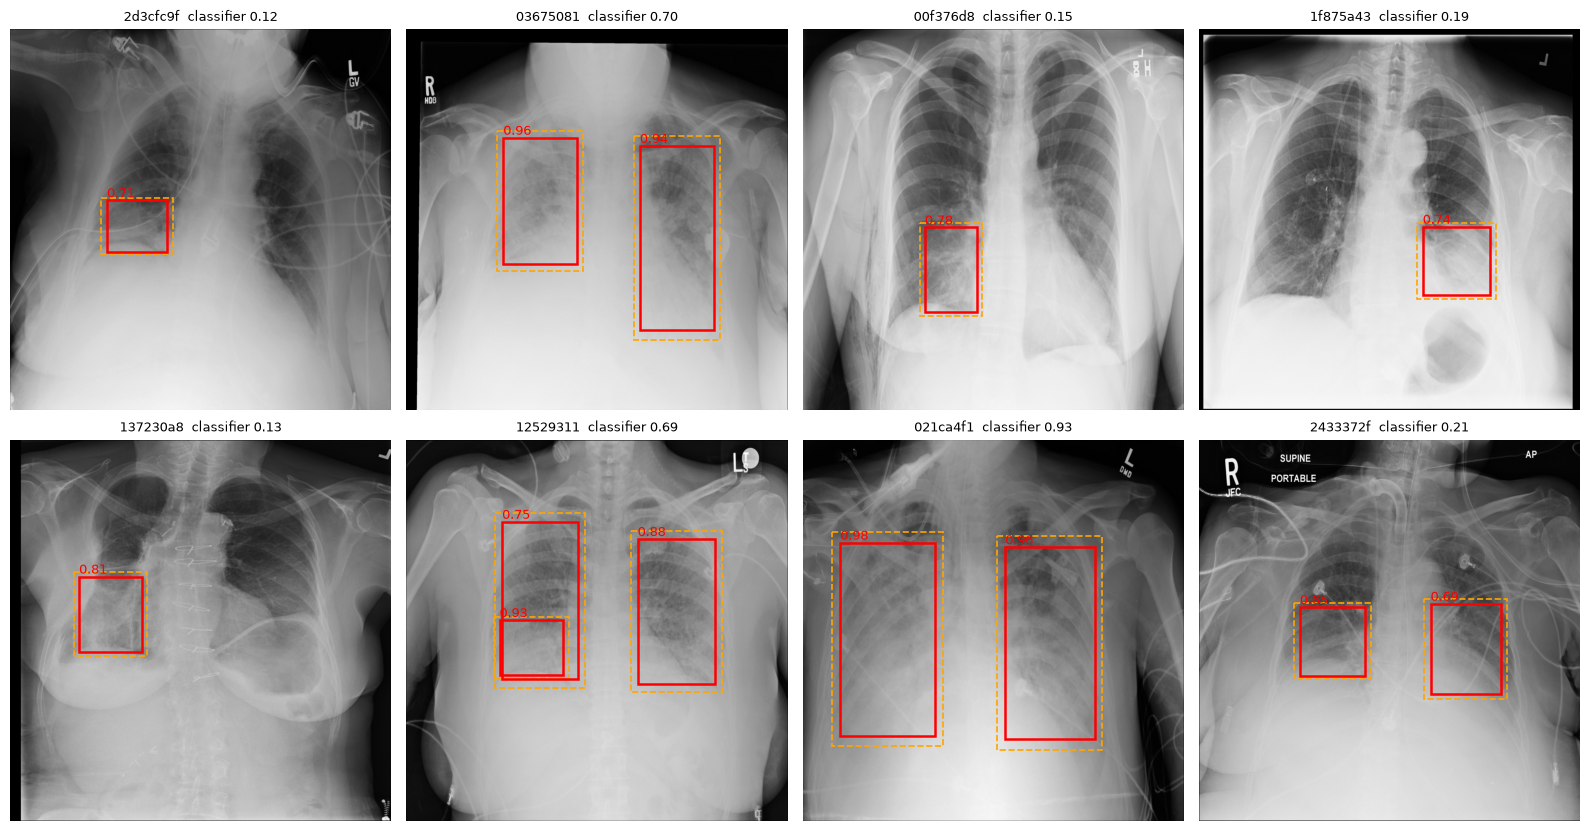

In [6]:
import matplotlib.pyplot as plt
import pydicom
from matplotlib.patches import Rectangle


def parse(s):
    return np.array(s.split(), float).reshape(-1, 5) if isinstance(s, str) and s else np.empty((0, 5))


saved = pd.read_csv(files["A"]).set_index("patientId")["PredictionString"]
unshrunk = to_pixels(fused).groupby("patient_id")
shown = np.random.default_rng(0).choice(saved.dropna().index, 8, replace=False)
fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
for ax, pid in zip(axes.flat, shown):
    ax.imshow(pydicom.dcmread(paths["raw_data_dir"] / "stage_2_test_images" / f"{pid}.dcm").pixel_array, cmap="gray")
    for _, b in unshrunk.get_group(pid).iterrows():
        ax.add_patch(Rectangle((b["x"], b["y"]), b["width"], b["height"], fill=False, ec="orange", ls="--", lw=1.2))
    for c, x, y, w, h in parse(saved[pid]):
        ax.add_patch(Rectangle((x, y), w, h, fill=False, ec="red", lw=1.8))
        ax.text(x, y - 8, f"{c:.2f}", color="red", fontsize=9)
    ax.set_title(f"{pid[:8]}  classifier {classifier[pid]:.2f}", fontsize=9)
    ax.axis("off")
plt.tight_layout()

**Finding:** the coordinates are right: every box sits on a lung, over the opacity, with no flipped or scaled boxes. Most images have one box per lung, as in the training labels. One image (12529311) keeps a small box inside a large one in the same lung: their IoU is below the WBF's 0.4. The 1st place kept such nested boxes too (an NMS over the final boxes lowered their score).

## 5. Why does the test score fall short of the consensus out-of-fold score?

Private scores: A 0.2067, B 0.2035, C 0.2029 (the public leaderboard uses about 1% of the test images and is ignored). The order matches 06, but 06 expected about 0.267 (held out) on the consensus images. The top teams scored about the same on the stage-1 test images and on stage 2 (1st 0.260 / 0.255, 3rd 0.238 / 0.239), so a drop of 0.06 points to something of our own. Checks that need no test labels:
1. **Image order:** is row *i* of the test array the DICOM of test id *i*?
2. **Classifier scores:** test against the out-of-fold scores of the two subsets.
3. **Detector scores and flip agreement:** per fold model, test against its own validation images.
4. **Near-duplicates:** does a consensus image have a near-copy among the other training images (e.g. another X-ray of the same patient), more often than a test image does? Out-of-fold scores would then be too high.

**1. Image order:** correlation between 20 random rows of `npy_256/test.npy` and their DICOMs (resized to 256), against the next test id's DICOM as a baseline:

In [7]:
from PIL import Image

processed = paths["processed_data_dir"]
test_npy = np.load(processed / "npy_256" / "test.npy", mmap_mode="r")
assert (pd.read_csv(processed / "test.csv")["patient_id"].to_numpy() == test_ids).all()


def dicom_256(pid):
    a = pydicom.dcmread(paths["raw_data_dir"] / "stage_2_test_images" / f"{pid}.dcm").pixel_array
    return np.asarray(Image.fromarray(a).resize((256, 256), Image.BILINEAR), float).ravel()


rows = np.random.default_rng(0).choice(len(test_ids), 20, replace=False)
own = [np.corrcoef(test_npy[i].ravel(), dicom_256(test_ids[i]))[0, 1] for i in rows]
other = [np.corrcoef(test_npy[i].ravel(), dicom_256(test_ids[(i + 1) % len(test_ids)]))[0, 1] for i in rows]
print(f"own DICOM: min {min(own):.3f}, mean {np.mean(own):.3f}; next id's DICOM: mean {np.mean(other):.3f}, max {max(other):.3f}")

own DICOM: min 0.999, mean 1.000; next id's DICOM: mean 0.537, max 0.841


**2. Classifier scores** (04 stack, test scores averaged over the fold models), test against out-of-fold:

In [8]:
patients = pd.read_csv(processed / "patients.csv")
oof = pd.read_csv(paths["outputs_dir"] / "classification" / "stack_384" / "oof_preds.csv").set_index("patient_id").loc[patients["patient_id"]]
is_cons = patients["is_stage1_test"].to_numpy()
groups = {"single reader (OOF)": oof["p_pneumonia"][~is_cons], "consensus (OOF)": oof["p_pneumonia"][is_cons], "test": classifier}
pd.DataFrame({name: {"images": len(s), "mean": s.mean(), "median": s.median(), ">= 0.1": (s >= 0.1).mean(),
                     ">= 0.5": (s >= 0.5).mean(), ">= 0.9": (s >= 0.9).mean()} for name, s in groups.items()}).T

,images,mean,median,>= 0.1,>= 0.5,>= 0.9
single reader (OOF),25684.0,0.2252,0.0739,0.4513,0.1863,0.0294
consensus (OOF),1000.0,0.2207,0.0700,0.4470,0.1800,0.0260
test,3000.0,0.2290,0.0823,0.4667,0.1943,0.0283


**3. Detector scores and flip agreement** per fold model: share of images whose top box reaches the threshold 0.6 (scores mapped as in section 1, before WBF and gating), and share of images where the top box of the original and of the flipped image overlap (IoU > 0.4). Validation images split into the two subsets:

In [9]:
fold_of_id = dict(zip(patients["patient_id"], patients["fold"]))
cons_ids = set(patients["patient_id"][is_cons])


def top_box(pred):
    return pred.sort_values("confidence", ascending=False).drop_duplicates("patient_id").set_index("patient_id")


def flip_agree(run, cfg, split):
    o, f = (top_box(nms_at(pd.read_csv(DET / run / f"{split}_preds{s}.csv"), cfg["nms_iou"])) for s in ("", "_flip"))
    both = o.index.intersection(f.index)
    a, b = o.loc[both, ["x", "y", "width", "height"]].to_numpy(float), f.loc[both, ["x", "y", "width", "height"]].to_numpy(float)
    w = np.clip(np.minimum(a[:, 0] + a[:, 2], b[:, 0] + b[:, 2]) - np.maximum(a[:, 0], b[:, 0]), 0, None)
    h = np.clip(np.minimum(a[:, 1] + a[:, 3], b[:, 1] + b[:, 3]) - np.maximum(a[:, 1], b[:, 1]), 0, None)
    inter = w * h
    return pd.Series(inter / (a[:, 2] * a[:, 3] + b[:, 2] * b[:, 3] - inter) > 0.4, index=both)


def detector_check(name, k, run, cfg):
    val = tta_boxes(run, cfg, "val")
    top_val = to_oof_rank(val, val).groupby("patient_id")["confidence"].max()
    top_test = test_boxes[name, k].groupby("patient_id")["confidence"].max().reindex(test_ids, fill_value=0)
    val_ids = patients["patient_id"][patients["fold"] == k]
    top_val = top_val.reindex(val_ids, fill_value=0)
    in_cons = top_val.index.isin(cons_ids)
    agree_val, agree_test = flip_agree(run, cfg, "val"), flip_agree(run, cfg, "test")
    return {"model": name, "fold": k,
            "top >= 0.6, single reader": (top_val[~in_cons] >= 0.6).mean(), "top >= 0.6, consensus": (top_val[in_cons] >= 0.6).mean(),
            "top >= 0.6, test": (top_test >= 0.6).mean(),
            "flip agree, single reader": agree_val[~agree_val.index.isin(cons_ids)].mean(),
            "flip agree, consensus": agree_val[agree_val.index.isin(cons_ids)].mean(), "flip agree, test": agree_test.mean()}


checks = pd.DataFrame(Parallel(n_jobs=8)(delayed(detector_check)(*job) for job in jobs)).set_index(["model", "fold"])
checks

top >= 0.6, single reader  top >= 0.6, consensus  top >= 0.6, test  flip agree, single reader  flip agree, consensus  flip agree, test
model          fold                                                                                                                                        
FRCNN-ConvNeXt 0                        0.5822                 0.6378            0.5777                     0.8464                 0.8247            0.8528
               1                        0.5847                 0.5484            0.5880                     0.7869                 0.7939            0.7958
               2                        0.6337                 0.6065            0.6167                     0.8418                 0.8462            0.8461
               3                        0.5915                 0.5877            0.5907                     0.7940                 0.8086            0.8091
               4                        0.4921                 0.5131            0.5083                     0.8455                 0.8605            0.8513
FCOS-MViT      0                        0.8670                 0.8980            0.8663                     0.8061                 0.8112            0.8117
               1                        0.8593                 0.8656            0.8630                     0.8111                 0.8333            0.8317
               2                        0.8645                 0.8519            0.8647                     0.7875                 0.8056            0.7930
               3                        0.8324                 0.8341            0.8383                     0.8020                 0.7820            0.8020
               4                        0.8614                 0.8482            0.8713                     0.8142                 0.8115            0.8147
YOLO26s        0                        0.3307                 0.3571            0.3353                     0.8346                 0.7845            0.8316
               1                        0.3296                 0.2903            0.3330                     0.8442                 0.8229            0.8456
               2                        0.3271                 0.3148            0.3280                     0.8351                 0.8276            0.8495
               3                        0.3141                 0.2891            0.3173                     0.8421                 0.8252            0.8477
               4                        0.3055                 0.2880            0.3227                     0.8336                 0.8687            0.8508

**4. Near-duplicates:** every image reduced to 32 × 32 (mean of 8 × 8 pixel blocks of the 256 × 256 array), standardised; cosine similarity to its most similar training image (itself excluded). Consensus images, 3,000 random single-reader images and the test images:

In [10]:
def small(a):
    s = a.reshape(len(a), 32, 8, 32, 8).mean((2, 4)).reshape(len(a), -1)
    s = s - s.mean(1, keepdims=True)
    return (s / np.linalg.norm(s, axis=1, keepdims=True)).astype(np.float32)


train_npy = np.load(processed / "npy_256" / "train.npy", mmap_mode="r")
train_small = np.concatenate([small(np.asarray(train_npy[i:i + 2000], np.float32)) for i in range(0, len(train_npy), 2000)])
test_small = small(np.asarray(test_npy, np.float32))


def nearest(q, exclude=None):
    sim = q @ train_small.T
    if exclude is not None:
        sim[np.arange(len(q)), exclude] = -1
    return sim.max(1), sim.argmax(1)


cons_rows = np.flatnonzero(is_cons)
single_rows = np.random.default_rng(0).choice(np.flatnonzero(~is_cons), 3000, replace=False)
near = {"consensus": nearest(train_small[cons_rows], cons_rows), "single reader (3,000)": nearest(train_small[single_rows], single_rows),
        "test": nearest(test_small)}
pd.DataFrame({name: {"median": np.median(s), "> 0.95": (s > 0.95).mean(), "> 0.98": (s > 0.98).mean(),
                     "> 0.99": (s > 0.99).mean()} for name, (s, _) in near.items()}).T

,median,> 0.95,> 0.98,> 0.99
consensus,0.9218,0.1320,0.0020,0.0000
"single reader (3,000)",0.9240,0.1327,0.0007,0.0000
test,0.9225,0.1167,0.0030,0.0007


**Finding:** none of the checks shows a fault on our side.
1. The test array is in the right order (correlation 0.999–1.000 with its own DICOM, at most 0.84 with another).
2. The classifier scores the test images like the training images (mean 0.229 vs 0.221–0.225; 19% above 0.5 vs 18–19%). Notably the consensus images, with 35% positives, get the same scores as the single-reader ones with 22%: the extra positives are a labelling effect (majority vote of 3 readers), not something the images show.
3. Every fold model puts a box at or above 0.6 on as many test images as on its validation images, and the original and flipped views agree as often (80–85%): the test predictions and the flip TTA behave as on validation.
4. Consensus images have no more near-copies in the training set than single-reader or test images (similarity above 0.98: 0.2% / 0.07% / 0.3%), so near-copies do not inflate the out-of-fold scores more than the test score. This check would not find another X-ray of the same patient taken on another day; but such X-rays are about as common for the validation as for the test images (02, section 3).

The checks point to the labels rather than the predictions; only submissions can locate the gap.

## 6. Diagnostic submissions

Each file changes one thing in A, to find which step loses on the test set. Next to each, the score it gets out-of-fold on the consensus images, rebuilt here from the 05 validation boxes (check: A gives 06's 0.2753, D1 gives 0.1727):

| file | change from A |
|---|---|
| D1 | the 05 ensemble as it is: no shrink, threshold 0.8, no gating |
| D2 | no gating |
| D3–D6 | box threshold 0.4 / 0.5 / 0.7 / 0.8 |
| D7 | fold 0 only (one fold trio instead of the 5 fused); out-of-fold, every image is predicted by one fold trio, so its expected score is A's |

In [11]:
from rsna.metrics import score_images

cons_list = patients["patient_id"][is_cons].to_numpy()
oof_classifier = oof["p_pneumonia"]


def oof_consensus(run, cfg):
    """One fold model's validation boxes on the consensus images, ranked among all its validation boxes."""
    val = tta_boxes(run, cfg, "val")
    return to_oof_rank(val, val).pipe(lambda p: p[p["patient_id"].isin(set(cons_list))])


parts = Parallel(n_jobs=8)(delayed(oof_consensus)(run, cfg) for _, _, run, cfg in jobs)
per_model = [pd.concat([p for (n, *_), p in zip(jobs, parts) if n == name], ignore_index=True) for name in names]
oof_boxes = wbf(per_model, weights, wbf_iou)


def oof_score(sx, sy, threshold, cutoff):
    p = shrink(oof_boxes, sx, sy)
    gated = set(oof_classifier.index[oof_classifier >= cutoff])
    p = p[(p["confidence"] >= threshold) & p["patient_id"].isin(gated)]
    return np.nanmean(score_images(true, p, cons_list).to_numpy())


def test_file(pred, sx, sy, threshold, cutoff):
    p = shrink(pred, sx, sy)
    return p[(p["confidence"] >= threshold) & p["patient_id"].isin(set(test_ids[classifier.to_numpy() >= cutoff]))]


def check_at(sub, threshold):
    assert len(sub) == len(sample) and sub["patientId"].is_unique
    for s in sub["PredictionString"][sub["PredictionString"] != ""]:
        v = np.array(s.split(), float).reshape(-1, 5)
        assert ((v[:, 0] >= threshold) & (v[:, 1:3] >= 0).all(1) & (v[:, 3:] > 0).all(1)
                & (v[:, 1] + v[:, 3] <= 1024) & (v[:, 2] + v[:, 4] <= 1024)).all()


a = POST["submissions"]["A"]
sa, ha = a["shrink_width"], a["shrink_height"]
diagnostics = {"A": ("as submitted", options["5 folds fused"], sa, ha, thr, cut),
               "D1": ("05 as it is", options["5 folds fused"], 1.0, 1.0, ENSEMBLE["threshold"], 0),
               "D2": ("no gating", options["5 folds fused"], sa, ha, thr, 0),
               **{f"D{3 + i}": (f"threshold {t}", options["5 folds fused"], sa, ha, t, cut) for i, t in enumerate([0.4, 0.5, 0.7, 0.8])},
               "D7": ("fold 0 only", options["fold 0 trio"], sa, ha, thr, cut)}
rows = {}
for name, (change, pred, sx, sy, t, c) in diagnostics.items():
    p = test_file(pred, sx, sy, t, c)
    if name != "A":
        sub = to_submission(p)
        check_at(sub, t)
        sub.to_csv(SUB_DIR / f"submission_{name}.csv", index=False)
    rows[name] = {"change": change, "consensus OOF": oof_score(sx, sy, t, c) if name != "D7" else np.nan,
                  "test images with a box": p["patient_id"].nunique() / len(test_ids), "test boxes": len(p)}
pd.DataFrame(rows).T

,change,consensus OOF,test images with a box,test boxes
A,as submitted,0.2753,0.411,2060
D1,05 as it is,0.1727,0.2423,1118
D2,no gating,0.2685,0.4403,2158
D3,threshold 0.4,0.2445,0.4613,2813
D4,threshold 0.5,0.2567,0.4457,2443
D5,threshold 0.7,0.2616,0.342,1620
D6,threshold 0.8,0.2,0.2407,1112
D7,fold 0 only,NaN,0.419,2199


**Private scores of the diagnostics** (consensus out-of-fold in brackets): D1 0.1593 (0.1727), D2 0.2014 (0.2685), thresholds 0.4 / 0.5 / 0.6 / 0.7 / 0.8: 0.1865 / 0.1989 / 0.2067 / 0.2109 / 0.1870 (0.2445 / 0.2567 / 0.2753 / 0.2616 / 0.2000), D7 0.2023.

**Finding:** the shrink and the gating carry over to the test set as measured (at threshold 0.8, shrink and gating add +0.028 on the test set, +0.027 out-of-fold; gating alone +0.005 vs +0.007), and fusing the 5 folds adds +0.004 over one fold. What does not carry over is the lower threshold: from 0.8 to 0.6 the consensus images gain +0.075, the test set +0.020. The test set's best threshold is about 0.7, between the single-reader (0.8) and the consensus images (0.6). Why is not clear. A lower share of positives in the test labels than in the consensus images (35%) would explain it, but that share is not published, and predictions cannot reveal it: section 5 found that the classifier scores the consensus and the single-reader images alike although 35% and 22% of them are positive. For the same reason, the similar shares of positives the 1st place predicted on the stage-1 and stage-2 test images (35% and 37%) say nothing about their labels.

## 7. Tuning on the leaderboard

From here the settings are chosen on the private leaderboard, i.e. on the test set itself, so the best of these scores is optimistic; A (0.2067) stays the score chosen before any submission. Box threshold 0.65 / 0.7 / 0.75 × the 3 shrinks of 06, gating at 0.1 (0.7 with A's shrink is D5, already submitted):

In [12]:
grid = {}
for t in (0.65, 0.7, 0.75):
    for k, s in POST["submissions"].items():
        sx, sy = s["shrink_width"], s["shrink_height"]
        name = f"E_{t:.2f}_{k}"
        p = test_file(options["5 folds fused"], sx, sy, t, cut)
        if (t, k) != (0.7, "A"):
            sub = to_submission(p)
            check_at(sub, t)
            sub.to_csv(SUB_DIR / f"submission_{name}.csv", index=False)
        grid[name] = {"threshold": t, "shrink": f"{sx} x {sy}", "consensus OOF": oof_score(sx, sy, t, cut),
                      "test images with a box": p["patient_id"].nunique() / len(test_ids), "file": "D5" if (t, k) == (0.7, "A") else f"submission_{name}.csv"}
pd.DataFrame(grid).T

,threshold,shrink,consensus OOF,test images with a box,file
E_0.65_A,0.65,0.85 x 0.9,0.2704,0.3833,submission_E_0.65_A.csv
E_0.65_B,0.65,0.8 x 0.85,0.2632,0.3833,submission_E_0.65_B.csv
E_0.65_C,0.65,0.9 x 0.95,0.2624,0.3833,submission_E_0.65_C.csv
E_0.70_A,0.7,0.85 x 0.9,0.2616,0.342,D5
E_0.70_B,0.7,0.8 x 0.85,0.256,0.342,submission_E_0.70_B.csv
E_0.70_C,0.7,0.9 x 0.95,0.2522,0.342,submission_E_0.70_C.csv
E_0.75_A,0.75,0.85 x 0.9,0.2329,0.2943,submission_E_0.75_A.csv
E_0.75_B,0.75,0.8 x 0.85,0.2294,0.2943,submission_E_0.75_B.csv
E_0.75_C,0.75,0.9 x 0.95,0.2243,0.2943,submission_E_0.75_C.csv


**Private scores** (consensus out-of-fold in brackets):

| box threshold | A: 0.85 × 0.90 | B: 0.80 × 0.85 | C: 0.90 × 0.95 |
|---|---|---|---|
| 0.6 (06's choice) | 0.2067 (0.2753) | 0.2035 (0.2681) | 0.2029 (0.2668) |
| 0.65 | **0.2113** (0.2704) | 0.2081 (0.2632) | 0.2072 (0.2624) |
| 0.7 | 0.2109 (0.2616) | 0.2086 (0.2560) | 0.2059 (0.2522) |
| 0.75 | 0.2041 (0.2329) | 0.2017 (0.2294) | 0.1986 (0.2243) |

**Finding:** A's shrink is the best at every threshold, as in 06. The test set is best at 0.65–0.7, a flat top; over 06's 0.6 this gains only +0.005. Further tuning on the leaderboard would gain little and fit the test set itself, so it stops here.

## 8. Summary

- **Test predictions:** each fold model's test scores are placed in the distribution of its own out-of-fold scores, so the 06 threshold keeps its meaning; the 3 detectors of each fold are fused as in 05, and the 5 fold trios by WBF. Order, scores and flip TTA of the test predictions behave as on validation (section 5).
- **Score chosen before any submission:** A (shrink 0.85 × 0.90, box threshold 0.6, classifier cut-off 0.1), private **0.2067**. 06 expected 0.267 from the consensus images (held out).
- **Where the gap comes from:** the shrink and the gating carry over to the test set as measured; the lower threshold does not (from 0.8 to 0.6: +0.075 on the consensus images, +0.020 on the test set). The test set's best threshold lies between those of the single-reader and the consensus images; why is not clear (section 6).
- **Tuned on the leaderboard:** box threshold 0.65 with A's shrink, private **0.2113**. Optimistic, since it was picked on the test set.
- **For scale** (private leaderboard, 344 teams): 1st 0.2548, 10th about 0.225, about 50th 0.192. The top teams post-processed in a similar way (box shrink), so the remaining gap is more likely in the models.
- **Limits:** the public leaderboard uses about 1% of the test images and is not used. 18 submissions were made in all (A–C, 7 diagnostics, 8 for tuning); A, B and C are the only ones chosen without the leaderboard.